# Python vs Rust 전처리: 코어 수별 성능 비교 (Linux)

**목적:** QDF 전처리(`profile_preprocess.py`)를 CPU 코어 수를 1→2→3→4로 늘리면서  
- **Python (NumPy)**: `multiprocessing` — N개 프로세스에 분자 묶음을 분배  
- **Rust (Rayon)**: `RAYON_NUM_THREADS` 환경변수로 스레드 수 제한  

두 가지 방식의 wall time·처리량·speedup·병렬 효율(%)을 나란히 봅니다.

| 항목 | Python 멀티프로세싱 | Rust Rayon |
|------|-------------------|------------|
| 병렬 단위 | 프로세스 (GIL 우회) | OS 스레드 (공유 메모리) |
| 병렬화 레버 | `multiprocessing.Pool` | `RAYON_NUM_THREADS` |
| 오버헤드 | 프로세스 생성 + IPC | 스레드 생성 (경량) |
| 메모리 | N × 데이터 복사 | 공유 (sphere 등 공유 가능) |

머신: **Neoverse-N1, 4물리코어, 1스레드/코어**

In [53]:
from __future__ import annotations

import os
import re
import subprocess
import sys
import tempfile
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── 레포 루트 탐색 (연구노트.md 우선, fallback: dataset) ────────────
REPO = Path.cwd().resolve()
for _p in [REPO, *REPO.parents]:
    if (_p / "연구노트.md").is_file():
        REPO = _p
        break
else:
    for _p in [REPO, *REPO.parents]:
        if (_p / "QuantumDeepField_molecule" / "dataset").is_dir():
            REPO = _p
            break

QDF_ROOT   = REPO / "QuantumDeepField_molecule"
PROFILE_PY = QDF_ROOT / "bench" / "profile_preprocess.py"
DATASET    = "QM9under14atoms_atomizationenergy_eV"
TRAIN_TXT  = QDF_ROOT / "dataset" / DATASET / "train.txt"
PYTHON     = str(Path(sys.executable))

# ── venv python 우선 사용 (qdf_io 설치 위치) ──────────────────────
VENV_PYTHON = REPO / ".venv" / "bin" / "python"
if VENV_PYTHON.is_file():
    PYTHON = str(VENV_PYTHON)

LOGICAL_CORES = os.cpu_count() or 4
CORE_CANDIDATES = sorted({c for c in (1, 2, 3, min(4, LOGICAL_CORES), LOGICAL_CORES) if c <= LOGICAL_CORES})

# ── 분자 수 (SMOKE=True → 빠른 스모크 테스트) ────────────────────
SMOKE       = True
N_MOLECULES = 200 if SMOKE else 1000   # 전체 분자 수 (N workers 합산)
RUST_BATCH  = 64

print(f"REPO          : {REPO}")
print(f"PYTHON        : {PYTHON}")
print(f"Logical cores : {LOGICAL_CORES}")
print(f"Core sweep    : {CORE_CANDIDATES}")
print(f"N_MOLECULES   : {N_MOLECULES}  (SMOKE={SMOKE})")
print(f"RUST_BATCH    : {RUST_BATCH}")


REPO          : /home/ubuntu/3DGCL
PYTHON        : /home/ubuntu/3DGCL/.venv/bin/python
Logical cores : 4
Core sweep    : [1, 2, 3, 4]
N_MOLECULES   : 200  (SMOKE=True)
RUST_BATCH    : 64


## 1. 데이터 준비 — 슬라이스 파일 생성

Python 멀티프로세싱 벤치는 N개 분자 묶음을 N개 임시 파일로 나눠서  
각 subprocess에 독립적으로 넘깁니다. (IPC 직렬화 비용 최소화)

In [54]:
def load_blocks(path: Path, limit: int) -> list[str]:
    text = path.read_text(encoding="utf-8").strip()
    blocks = text.split("\n\n")
    return blocks[:limit]


# 전체 N_MOLECULES 개 블록 로드
ALL_BLOCKS = load_blocks(TRAIN_TXT, N_MOLECULES)
print(f"Loaded {len(ALL_BLOCKS)} molecule blocks")
print(f"First block preview: {ALL_BLOCKS[0][:60]!r} ...")

Loaded 200 molecule blocks
First block preview: 'dsgdb9nsd_000001\nC -0.0127 1.0858 0.008\nH 0.0022 -0.006 0.00' ...


In [55]:
# 슬라이스 파일 쓰기 유틸 (각 벤치 반복 시 재사용)
_TMPDIR = tempfile.mkdtemp(prefix="qdf_core_bench_")
TMPDIR  = Path(_TMPDIR)


def write_slices(blocks: list[str], n_workers: int) -> list[Path]:
    """blocks 를 n_workers 개 파일로 균등 분할 저장."""
    chunk = len(blocks) // n_workers
    paths: list[Path] = []
    for i in range(n_workers):
        start = i * chunk
        end   = start + chunk if i < n_workers - 1 else len(blocks)
        fpath = TMPDIR / f"slice_{n_workers}w_{i}.txt"
        fpath.write_text("\n\n".join(blocks[start:end]), encoding="utf-8")
        paths.append(fpath)
    return paths


print(f"임시 디렉터리: {TMPDIR}")

임시 디렉터리: /tmp/qdf_core_bench_8uk_aqfn


## 2. 벤치 헬퍼 함수

`profile_preprocess.py` 는 `--dataset`/`--split` 경로 고정이므로,  
슬라이스용 **인라인 벤치** 함수를 따로 구현합니다.  
Python 멀티프로세싱 벤치는 `subprocess` 를 병렬로 띄워 외벽 시간을 측정합니다.  
**숫자 NumPy(순차)** 는 `ProcessPoolExecutor` 없이 전체 분자를 한 번의 서브프로세스에서 `--backend numpy` 와 동일한 단일 루프로 측정합니다 (BLAS 스레드 1).


In [56]:
def _run_profile(slice_path: Path, backend: str, rust_batch: int,
                 extra_env: dict | None = None) -> tuple[float | None, str]:
    """profile_preprocess.py 를 단일 슬라이스 파일에 대해 실행.

    profile_preprocess.py 는 --dataset / --split 경로가 고정이므로
    슬라이스 처리를 위해 인라인 벤치 스크립트를 문자열로 생성합니다.
    """
    n_mol = slice_path.read_text(encoding="utf-8").count("\n\n") + 1

    inline_script = f"""
import sys, time, resource
from pathlib import Path
sys.path.insert(0, r"{QDF_ROOT / 'train'}")
sys.path.insert(0, r"{QDF_ROOT / 'bench'}")
from profile_preprocess import load_dataset_blocks, time_preprocess_pipeline

blocks = load_dataset_blocks(Path(r"{slice_path}"))
wall, timings, n_mol, _, _bench_meta = time_preprocess_pipeline(
    blocks,
    backend={backend!r},
    rust_batch_size={rust_batch},
    basis_set="6-31G",
    radius=0.75,
    grid_interval=0.3,
    has_property=True,
    no_save=True,
)
print(f"wall time     : {{wall:.4f}} s")
print(f"n_molecules   : {{n_mol}}")
for k, v in sorted(timings.items(), key=lambda x: -x[1]):
    share = 100.0 * v / wall if wall else 0
    print(f"step {{k:22s}}: {{v:.4f}} s  {{share:5.1f}}%")
# Linux: ru_maxrss is kilobytes (see getrusage(2)). Other OS may differ.
_mu = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
print(f"maxrss_kb     : {{int(_mu)}}")
"""

    env = os.environ.copy()
    if extra_env:
        env.update(extra_env)

    cp = subprocess.run(
        [PYTHON, "-c", inline_script],
        capture_output=True, text=True,
        encoding="utf-8", errors="replace",
        env=env,
        cwd=str(REPO),
    )
    stdout = cp.stdout or ""
    m = re.search(r"wall time\s*:\s*([\d.]+)", stdout)
    wall = float(m.group(1)) if m else None
    return wall, stdout + (cp.stderr or "")


print("헬퍼 함수 정의 완료")


헬퍼 함수 정의 완료


In [57]:
def parse_maxrss_kb(output: str) -> int | None:
    m = re.search(r"maxrss_kb\s*:\s*(\d+)", output)
    return int(m.group(1)) if m else None


def parse_step_timings(output: str) -> dict[str, float]:
    """stdout 에서 'step <name>: X.XXXX s' 를 파싱."""
    result: dict[str, float] = {}
    for m in re.finditer(r"step\s+(\S+)\s*:\s*([\d.]+)\s+s", output):
        result[m.group(1)] = float(m.group(2))
    return result


def bench_python_nworkers(blocks: list[str], n_workers: int) -> dict:
    """Python multiprocessing: n_workers 개 프로세스를 병렬 실행.
    각 프로세스가 len(blocks)/n_workers 개 분자를 담당.
    외벽 시간 = max(worker wall time).
    """
    slice_paths = write_slices(blocks, n_workers)

    walls: list[float] = []
    rss_kb_list: list[int] = []
    step_totals: dict[str, float] = {}
    errors: list[str] = []

    t_outer_start = time.perf_counter()
    futures = {}
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        for sp in slice_paths:
            # Python은 OMP/BLAS 멀티스레드 비활성화 → CPU 경합 방지
            fut = ex.submit(_run_profile, sp, "numpy", RUST_BATCH,
                            {"OMP_NUM_THREADS": "1",
                             "OPENBLAS_NUM_THREADS": "1",
                             "MKL_NUM_THREADS": "1"})
            futures[fut] = sp

        for fut in as_completed(futures):
            w, out = fut.result()
            if w is not None:
                walls.append(w)
                rk = parse_maxrss_kb(out)
                if rk is not None:
                    rss_kb_list.append(rk)
                for k, v in parse_step_timings(out).items():
                    step_totals[k] = step_totals.get(k, 0.0) + v
            else:
                errors.append(out[-300:])

    t_outer_wall = time.perf_counter() - t_outer_start
    per_mol = len(blocks) // n_workers  # 워커 당 분자 수 (균등 분할 기준)

    rss_sum_mib = (sum(rss_kb_list) / 1024.0) if rss_kb_list else None
    rss_max_mib = (max(rss_kb_list) / 1024.0) if rss_kb_list else None

    return {
        "n_workers"    : n_workers,
        "outer_wall_s" : t_outer_wall,          # 실제 사용자 체감 시간
        "max_wall_s"   : max(walls) if walls else None,
        "worker_walls" : walls,
        "mols_per_worker": per_mol,
        "total_mols"   : len(blocks),
        "step_totals"  : step_totals,
        "errors"       : errors,
        "rss_kb_list"  : rss_kb_list,
        "rss_sum_mib"  : rss_sum_mib,
        "rss_max_mib"  : rss_max_mib,
    }


def bench_rust_nthreads(blocks: list[str], n_threads: int) -> dict:
    """Rust Rayon: 단일 프로세스로 RAYON_NUM_THREADS 제한."""
    # Rust 는 전체 분자를 한 번에 처리
    full_path = TMPDIR / "all_mols.txt"
    full_path.write_text("\n\n".join(blocks), encoding="utf-8")

    w, out = _run_profile(full_path, "rust", RUST_BATCH,
                          {"RAYON_NUM_THREADS": str(n_threads)})
    rk = parse_maxrss_kb(out)
    rss_mib = (rk / 1024.0) if rk is not None else None

    return {
        "n_threads"  : n_threads,
        "wall_s"     : w,
        "total_mols" : len(blocks),
        "step_totals": parse_step_timings(out),
        "raw_out"    : out,
        "rss_mib"    : rss_mib,
    }


def bench_python_sequential_numpy(blocks: list[str]) -> dict:
    """NumPy backend: single process, sequential per-molecule loop (no ProcessPoolExecutor).

    Matches ``profile_preprocess.py`` with ``--backend numpy`` on the full block list:
    one interpreter, one loop, BLAS threads pinned to 1.
    """
    full_path = TMPDIR / "all_mols_numpy_seq.txt"
    full_path.write_text("\n\n".join(blocks), encoding="utf-8")
    env = {
        "OMP_NUM_THREADS": "1",
        "OPENBLAS_NUM_THREADS": "1",
        "MKL_NUM_THREADS": "1",
    }
    w, out = _run_profile(full_path, "numpy", RUST_BATCH, env)
    rk = parse_maxrss_kb(out)
    rss_mib = (rk / 1024.0) if rk is not None else None
    return {
        "wall_s": w,
        "total_mols": len(blocks),
        "step_totals": parse_step_timings(out),
        "raw_out": out,
        "rss_mib": rss_mib,
    }


print("벤치 함수 정의 완료")


벤치 함수 정의 완료


## 3. 스모크 테스트 — 단일 코어 (Python · Rust 각 1회)

설정이 정상인지 확인합니다.

In [58]:
print("=== smoke: Python 1-worker ===")
r_py1 = bench_python_nworkers(ALL_BLOCKS, n_workers=1)
print(f"  outer_wall : {r_py1['outer_wall_s']:.3f} s")
print(f"  max_wall   : {r_py1['max_wall_s']} s")
if r_py1["errors"]:
    print("  ERRORS:", r_py1["errors"])

print()
print("=== smoke: Python NumPy sequential (no multiprocessing) ===")
r_seq_smoke = bench_python_sequential_numpy(ALL_BLOCKS)
print(f"  wall       : {r_seq_smoke['wall_s']} s")

print("=== smoke: Rust 1-thread ===")
r_rs1 = bench_rust_nthreads(ALL_BLOCKS, n_threads=1)
print(f"  wall       : {r_rs1['wall_s']} s")
if "error" in (r_rs1["raw_out"] or "").lower():
    print("  (possible error in output)")
    print(r_rs1["raw_out"][:400])


=== smoke: Python 1-worker ===
  outer_wall : 0.846 s
  max_wall   : 0.5611 s

=== smoke: Python NumPy sequential (no multiprocessing) ===
  wall       : 0.5754 s
=== smoke: Rust 1-thread ===
  wall       : 0.0867 s


## 4. 코어 수별 전체 스윕

코어 1, 2, 3, 4 에서 각각 실행.  
- **Python**: N 프로세스 병렬, 외벽(outer) 시간 기록  
- **Rust** : `RAYON_NUM_THREADS=N`, 단일 프로세스 전체 wall 기록

In [59]:
py_results:   list[dict] = []
rust_results: list[dict] = []

print("\n── Python (NumPy, sequential, no multiprocessing) ───")
py_seq_result = bench_python_sequential_numpy(ALL_BLOCKS)
if py_seq_result["wall_s"] is None:
    print("  ERROR:", (py_seq_result.get("raw_out") or "")[:300])
else:
    w0 = py_seq_result["wall_s"]
    print(f"  wall={w0:.3f}s  ({N_MOLECULES / w0:.1f} mol/s)")

for n in CORE_CANDIDATES:
    print(f"\n── {n} core(s) ────────────────────────")

    print(f"  [Python × {n} procs]")
    rp = bench_python_nworkers(ALL_BLOCKS, n_workers=n)
    py_results.append(rp)
    if rp["errors"]:
        print("  ERROR:", rp["errors"][0][:200])
    else:
        print(f"  outer_wall={rp['outer_wall_s']:.3f}s  "
              f"max_worker={rp['max_wall_s']:.3f}s  "
              f"({N_MOLECULES / rp['outer_wall_s']:.1f} mol/s)")

    print(f"  [Rust × {n} threads]")
    rr = bench_rust_nthreads(ALL_BLOCKS, n_threads=n)
    rust_results.append(rr)
    if rr["wall_s"] is None:
        print("  ERROR:")
        print(rr["raw_out"][:300])
    else:
        print(f"  wall={rr['wall_s']:.3f}s  "
              f"({N_MOLECULES / rr['wall_s']:.1f} mol/s)")

print("\n스윕 완료")



── Python (NumPy, sequential, no multiprocessing) ───
  wall=0.564s  (354.4 mol/s)

── 1 core(s) ────────────────────────
  [Python × 1 procs]
  outer_wall=0.814s  max_worker=0.548s  (245.8 mol/s)
  [Rust × 1 threads]
  wall=0.085s  (2364.1 mol/s)

── 2 core(s) ────────────────────────
  [Python × 2 procs]
  outer_wall=0.628s  max_worker=0.334s  (318.4 mol/s)
  [Rust × 2 threads]
  wall=0.060s  (3322.3 mol/s)

── 3 core(s) ────────────────────────
  [Python × 3 procs]
  outer_wall=0.558s  max_worker=0.255s  (358.5 mol/s)
  [Rust × 3 threads]
  wall=0.057s  (3521.1 mol/s)

── 4 core(s) ────────────────────────
  [Python × 4 procs]
  outer_wall=0.508s  max_worker=0.191s  (393.6 mol/s)
  [Rust × 4 threads]
  wall=0.048s  (4149.4 mol/s)

스윕 완료


## 5. 결과 집계 및 테이블

In [60]:
rows = []

# Python 기준(1코어) wall
py1_wall = py_results[0]["outer_wall_s"] if py_results else None
rs1_wall = rust_results[0]["wall_s"]     if rust_results else None
seq_wall = py_seq_result.get("wall_s") if py_seq_result else None

for rp in py_results:
    n = rp["n_workers"]
    w = rp["outer_wall_s"]
    rss = rp.get("rss_sum_mib")
    rows.append({
        "cores"         : n,
        "backend"       : "Python (multiprocessing)",
        "wall_s"        : round(w, 4),
        "rss_sum_mib"   : round(rss, 2) if rss is not None else None,
        "mol_per_s"     : round(N_MOLECULES / w, 1) if w else None,
        "ms_per_mol"    : round(1000 * w / N_MOLECULES, 2) if w else None,
        "speedup"       : round(py1_wall / w, 2) if (w and py1_wall) else None,
        "efficiency_pct": round(100 * py1_wall / w / n, 1) if (w and py1_wall) else None,
    })

for rr in rust_results:
    n = rr["n_threads"]
    w = rr["wall_s"]
    rss = rr.get("rss_mib")
    rows.append({
        "cores"         : n,
        "backend"       : "Rust (Rayon)",
        "wall_s"        : round(w, 4) if w else None,
        "rss_sum_mib"   : round(rss, 2) if rss is not None else None,
        "mol_per_s"     : round(N_MOLECULES / w, 1) if w else None,
        "ms_per_mol"    : round(1000 * w / N_MOLECULES, 2) if w else None,
        "speedup"       : round(rs1_wall / w, 2) if (w and rs1_wall) else None,
        "efficiency_pct": round(100 * rs1_wall / w / n, 1) if (w and rs1_wall) else None,
    })

# Flat reference: sequential NumPy does not use extra cores (same wall at each x).
seq_rss = py_seq_result.get("rss_mib")
if seq_wall:
    for n in CORE_CANDIDATES:
        w = seq_wall
        rows.append({
            "cores": n,
            "backend": "Python (numpy, sequential)",
            "wall_s": round(w, 4),
            "rss_sum_mib": round(seq_rss, 2) if seq_rss is not None else None,
            "mol_per_s": round(N_MOLECULES / w, 1),
            "ms_per_mol": round(1000 * w / N_MOLECULES, 2),
            "speedup": 1.0,
            "efficiency_pct": float("nan"),
        })


df = pd.DataFrame(rows).sort_values(["cores", "backend"]).reset_index(drop=True)

# Rust 1T 대비 Python 1W 차이 (단일 코어 speedup)

if seq_wall and py1_wall:
    print(f"Sequential NumPy vs 1-proc multiprocessing outer wall: {seq_wall:.3f}s vs {py1_wall:.3f}s  "
          f"(ratio {seq_wall/py1_wall:.2f}x)")

if py1_wall and rs1_wall:
    print(f"단일코어 Rust/Python 비율: {py1_wall/rs1_wall:.2f}x  "
          f"(Python {py1_wall:.3f}s vs Rust {rs1_wall:.3f}s)")

print()
display(df.to_string(index=False))


Sequential NumPy vs 1-proc multiprocessing outer wall: 0.564s vs 0.814s  (ratio 0.69x)
단일코어 Rust/Python 비율: 9.62x  (Python 0.814s vs Rust 0.085s)



' cores                    backend  wall_s  rss_sum_mib  mol_per_s  ms_per_mol  speedup  efficiency_pct\n     1   Python (multiprocessing)  0.8136       159.83      245.8        4.07     1.00           100.0\n     1 Python (numpy, sequential)  0.5643       195.25      354.4        2.82     1.00             NaN\n     1               Rust (Rayon)  0.0846       195.25     2364.1        0.42     1.00           100.0\n     2   Python (multiprocessing)  0.6281       319.68      318.4        3.14     1.30            64.8\n     2 Python (numpy, sequential)  0.5643       195.25      354.4        2.82     1.00             NaN\n     2               Rust (Rayon)  0.0602       195.25     3322.3        0.30     1.41            70.3\n     3   Python (multiprocessing)  0.5578       479.48      358.5        2.79     1.46            48.6\n     3 Python (numpy, sequential)  0.5643       195.25      354.4        2.82     1.00             NaN\n     3               Rust (Rayon)  0.0568       195.25     3521

## 6. 시각화

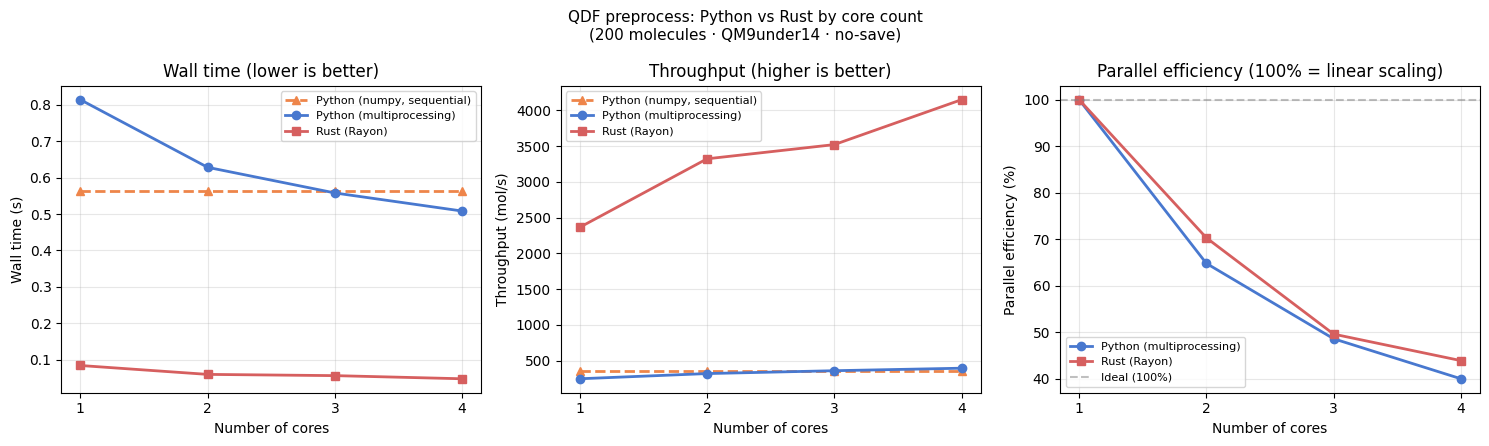

Saved: figs/python_vs_rust_per_core.png


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(
    f"QDF preprocess: Python vs Rust by core count\n"
    f"({N_MOLECULES} molecules · QM9under14 · no-save)",
    fontsize=11,
)

COLORS = {
    "Python (numpy, sequential)": "#EE854A",
    "Python (multiprocessing)": "#4878CF",
    "Rust (Rayon)": "#D65F5F",
}
MARKERS = {
    "Python (numpy, sequential)": "^",
    "Python (multiprocessing)": "o",
    "Rust (Rayon)": "s",
}
BACKENDS_WALL_TP = [
    "Python (numpy, sequential)",
    "Python (multiprocessing)",
    "Rust (Rayon)",
]
BACKENDS_EFF = ["Python (multiprocessing)", "Rust (Rayon)"]

for backend in BACKENDS_WALL_TP:
    sub = df[df["backend"] == backend].dropna(subset=["wall_s"])
    c, m = COLORS[backend], MARKERS[backend]
    ls = "--" if backend == "Python (numpy, sequential)" else "-"

    # (1) Wall time
    axes[0].plot(sub["cores"], sub["wall_s"], f"{m}{ls}", color=c, label=backend, lw=2)

    # (2) Throughput (mol/s)
    axes[1].plot(sub["cores"], sub["mol_per_s"], f"{m}{ls}", color=c, label=backend, lw=2)

    # (3) Parallel efficiency (only backends that scale)
    if backend in BACKENDS_EFF:
        sub_eff = sub.dropna(subset=["efficiency_pct"])
        if not sub_eff.empty:
            axes[2].plot(sub_eff["cores"], sub_eff["efficiency_pct"], f"{m}-",
                         color=c, label=backend, lw=2)

# Ideal linear reference
max_c = max(CORE_CANDIDATES)
ideal_x = [1, max_c]
ideal_y_mols = [None, None]
for ax in axes[2:3]:
    ax.axhline(100, ls="--", color="gray", alpha=0.5, label="Ideal (100%)")

for ax, ylabel, title in zip(
    axes,
    ["Wall time (s)", "Throughput (mol/s)", "Parallel efficiency (%)"],
    ["Wall time (lower is better)", "Throughput (higher is better)", "Parallel efficiency (100% = linear scaling)"],
):
    ax.set_xlabel("Number of cores")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(CORE_CANDIDATES)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = Path("figs") / "python_vs_rust_per_core.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## Memory by core (3 backends)

Each subprocess prints **Linux `getrusage().ru_maxrss`** in **kibibytes (KiB)** after the preprocess loop.

- **Python (multiprocessing):** **sum of per-worker peak RSS** (approximate concurrent footprint if all workers hit their peak together).
- **Python (numpy, sequential)** and **Rust (Rayon):** **single process** peak RSS (flat line for sequential across the x-axis).

This is **resident set**, not `VmSize`; it excludes shared pages counted per mapping on some kernels — use as a relative benchmark between runs on the same VM.


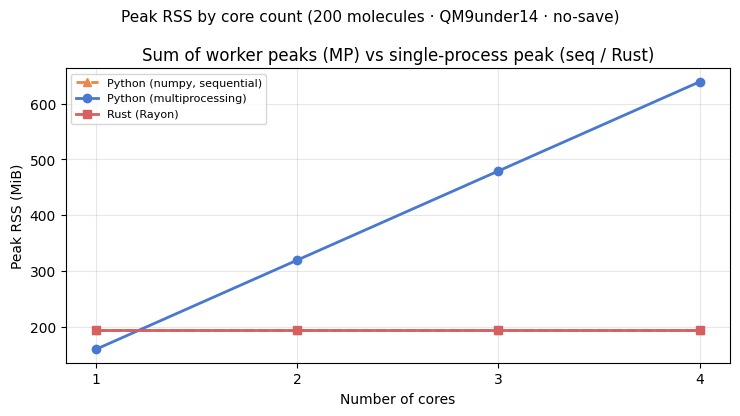

Saved: figs/memory_by_core_three_backends.png
 cores                    backend  rss_sum_mib  wall_s
     1   Python (multiprocessing)       159.83  0.8136
     1 Python (numpy, sequential)       195.25  0.5643
     1               Rust (Rayon)       195.25  0.0846
     2   Python (multiprocessing)       319.68  0.6281
     2 Python (numpy, sequential)       195.25  0.5643
     2               Rust (Rayon)       195.25  0.0602
     3   Python (multiprocessing)       479.48  0.5578
     3 Python (numpy, sequential)       195.25  0.5643
     3               Rust (Rayon)       195.25  0.0568
     4   Python (multiprocessing)       639.35  0.5082
     4 Python (numpy, sequential)       195.25  0.5643
     4               Rust (Rayon)       195.25  0.0482


In [62]:
# Peak RSS (MiB) vs number of cores — three backends
figm, axm = plt.subplots(figsize=(7.5, 4.2))
figm.suptitle(
    f"Peak RSS by core count ({N_MOLECULES} molecules · QM9under14 · no-save)",
    fontsize=11,
)

for backend in BACKENDS_WALL_TP:
    sub = df[df["backend"] == backend].dropna(subset=["rss_sum_mib"])
    if sub.empty:
        continue
    c, m = COLORS[backend], MARKERS[backend]
    ls = "--" if backend == "Python (numpy, sequential)" else "-"
    axm.plot(
        sub["cores"],
        sub["rss_sum_mib"],
        f"{m}{ls}",
        color=c,
        label=backend,
        lw=2,
    )

axm.set_xlabel("Number of cores")
axm.set_ylabel("Peak RSS (MiB)")
axm.set_title("Sum of worker peaks (MP) vs single-process peak (seq / Rust)")
axm.set_xticks(CORE_CANDIDATES)
axm.legend(fontsize=8)
axm.grid(alpha=0.3)
plt.tight_layout()
mem_path = Path("figs") / "memory_by_core_three_backends.png"
mem_path.parent.mkdir(exist_ok=True)
plt.savefig(mem_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {mem_path}")

# Optional: show RSS table alongside wall
cols = ["cores", "backend", "rss_sum_mib", "wall_s"]
print(df[cols].dropna(subset=["rss_sum_mib"]).to_string(index=False))


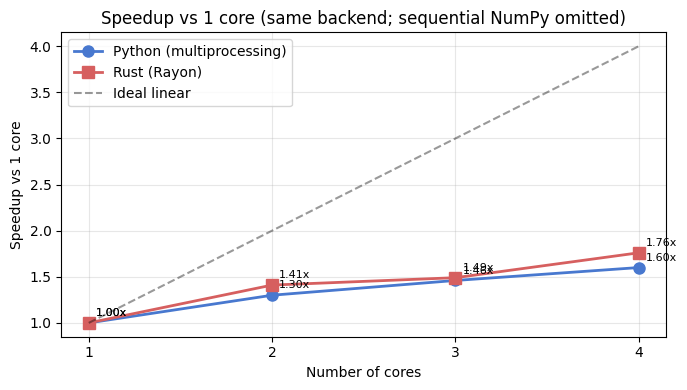

Saved: figs/python_vs_rust_speedup.png


In [63]:
# ── Speedup 비교 (1코어 대비) ──────────────────────────────────────
fig2, ax = plt.subplots(figsize=(7, 4))

for backend in ["Python (multiprocessing)", "Rust (Rayon)"]:
    sub = df[(df["backend"] == backend)].dropna(subset=["speedup"])
    c, m = COLORS[backend], MARKERS[backend]
    ax.plot(sub["cores"], sub["speedup"], f"{m}-", color=c, label=backend, lw=2, ms=8)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['speedup']:.2f}x",
                    (row["cores"], row["speedup"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)

# Ideal linear scaling
ideal = list(CORE_CANDIDATES)
ax.plot(ideal, ideal, "k--", alpha=0.4, label="Ideal linear")

ax.set_xlabel("Number of cores")
ax.set_ylabel("Speedup vs 1 core")
ax.set_title("Speedup vs 1 core (same backend; sequential NumPy omitted)")
ax.set_xticks(CORE_CANDIDATES)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig2_path = Path("figs") / "python_vs_rust_speedup.png"
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig2_path}")


## 7. 단계별(step) 시간 분해 — 4코어에서의 내부 구조

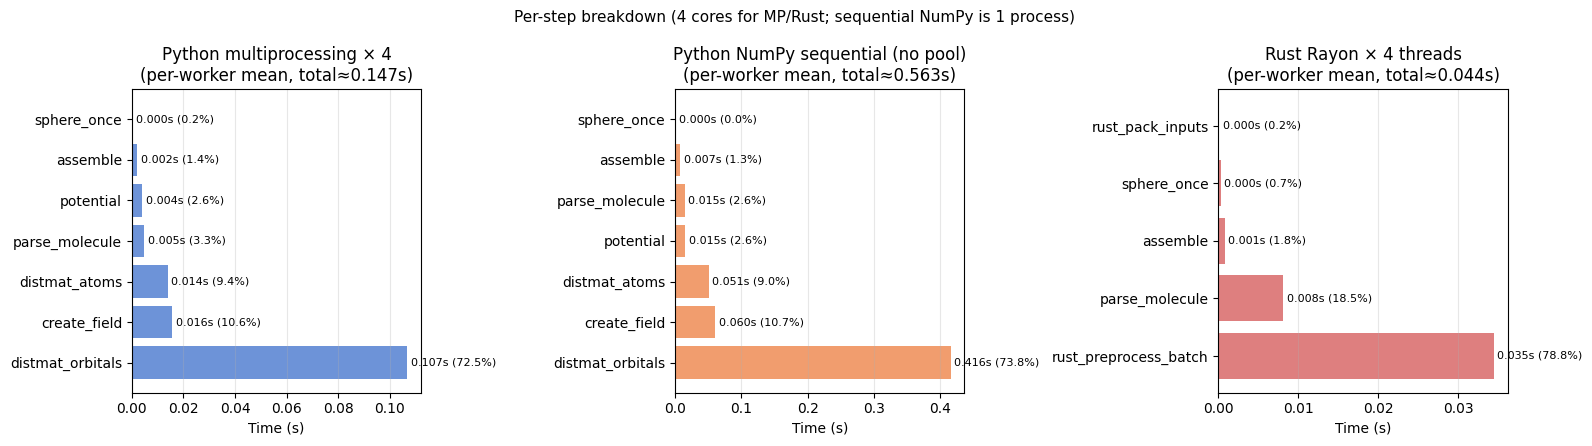

Saved: figs/python_vs_rust_steps.png


In [64]:
# Step breakdown at max cores + sequential NumPy baseline
max_n = max(CORE_CANDIDATES)

py_top = next((r for r in py_results if r["n_workers"] == max_n), py_results[-1])
rs_top = next((r for r in rust_results if r["n_threads"] == max_n), rust_results[-1])

# Python multiprocessing: sum worker steps / n_workers ≈ per-worker mean
py_mp_steps = {k: v / py_top["n_workers"] for k, v in py_top["step_totals"].items()}
# Sequential NumPy: single process totals
py_seq_steps = py_seq_result.get("step_totals") or {}
rs_steps = rs_top["step_totals"]

fig3, axes3 = plt.subplots(1, 3, figsize=(16, 4.5))
fig3.suptitle(
    f"Per-step breakdown ({max_n} cores for MP/Rust; sequential NumPy is 1 process)",
    fontsize=11,
)

for ax, steps, title, color in zip(
    axes3,
    [py_mp_steps, py_seq_steps, rs_steps],
    [
        f"Python multiprocessing × {max_n}",
        "Python NumPy sequential (no pool)",
        f"Rust Rayon × {max_n} threads",
    ],
    ["#4878CF", "#EE854A", "#D65F5F"],
):
    if not steps:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_title(title)
        continue
    labels = list(steps.keys())
    vals   = [steps[k] for k in labels]
    total  = sum(vals)
    bars = ax.barh(labels, vals, color=color, alpha=0.8)
    for bar, v in zip(bars, vals):
        ax.text(v + total * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}s ({100*v/total:.1f}%)", va="center", fontsize=8)
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{title}\n(per-worker mean, total≈{total:.3f}s)")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
fig3_path = Path("figs") / "python_vs_rust_steps.png"
plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig3_path}")


## 8. 종합 요약

In [65]:
print("="*65)
print(" Python vs Rust 전처리 — 코어별 성능 요약")
print("="*65)

print("\n[1] Throughput (mol/s)")
seq_mps = (N_MOLECULES / seq_wall) if seq_wall else None
print(f"  Sequential NumPy (once, no MP): {seq_mps}")
print(f"  {'cores':>5}  {'Python MP':>12}  {'Rust':>12}  {'Rust/MP':>12}")
for n in CORE_CANDIDATES:
    py_row = df[(df["cores"]==n) & (df["backend"]=="Python (multiprocessing)")]
    rs_row = df[(df["cores"]==n) & (df["backend"]=="Rust (Rayon)")]
    py_mps = py_row["mol_per_s"].values[0] if len(py_row) else None
    rs_mps = rs_row["mol_per_s"].values[0] if len(rs_row) else None
    ratio  = f"{rs_mps/py_mps:.2f}x" if (py_mps and rs_mps) else "N/A"
    print(f"  {n:>5}  {str(py_mps):>12}  {str(rs_mps):>12}  {ratio:>12}")

print("\n[2] 병렬 효율 (각 backend 내, 1코어 대비 스케일링)")
print(f"  {'cores':>5}  {'Python eff%':>12}  {'Rust eff%':>12}")
for n in CORE_CANDIDATES:
    py_row = df[(df["cores"]==n) & (df["backend"]=="Python (multiprocessing)")]
    rs_row = df[(df["cores"]==n) & (df["backend"]=="Rust (Rayon)")]
    py_eff = py_row["efficiency_pct"].values[0] if len(py_row) else None
    rs_eff = rs_row["efficiency_pct"].values[0] if len(rs_row) else None
    print(f"  {n:>5}  {str(py_eff):>12}  {str(rs_eff):>12}")

print()
print("[3] 해석 포인트")
print("  - Python NumPy sequential: 단일 프로세스 루프; 코어 수와 무관(가로 기준선)")
print("  - Python 멀티프로세싱: 프로세스 생성+IPC 오버헤드 → 2코어에서도 이상 대비 낮은 효율")
print("  - Rust Rayon: 스레드 공유 메모리 → 오버헤드 작고 효율 ↑")
print("  - 단일 코어 Rust/Python 비율이 높을수록, 코어를 늘려도 Python이 따라잡기 어려움")
print("  - 4코어 Rust ≈ (4코어 Python × Rust_단일코어_배율) 이 되면 이중 이득")
print()
print("[4] 권장 운영 설정 (4코어 Linux)")
print("  Rust : RAYON_NUM_THREADS=4 (기본값 OK)")
print("  Python : OMP_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 + 프로세스 4개")
print("  (전처리 한 번만 → --output-format shard 로 저장 후 학습 재사용 권장)")


 Python vs Rust 전처리 — 코어별 성능 요약

[1] Throughput (mol/s)
  Sequential NumPy (once, no MP): 354.421407052986
  cores     Python MP          Rust       Rust/MP
      1         245.8        2364.1         9.62x
      2         318.4        3322.3        10.43x
      3         358.5        3521.1         9.82x
      4         393.6        4149.4        10.54x

[2] 병렬 효율 (각 backend 내, 1코어 대비 스케일링)
  cores   Python eff%     Rust eff%
      1         100.0         100.0
      2          64.8          70.3
      3          48.6          49.6
      4          40.0          43.9

[3] 해석 포인트
  - Python NumPy sequential: 단일 프로세스 루프; 코어 수와 무관(가로 기준선)
  - Python 멀티프로세싱: 프로세스 생성+IPC 오버헤드 → 2코어에서도 이상 대비 낮은 효율
  - Rust Rayon: 스레드 공유 메모리 → 오버헤드 작고 효율 ↑
  - 단일 코어 Rust/Python 비율이 높을수록, 코어를 늘려도 Python이 따라잡기 어려움
  - 4코어 Rust ≈ (4코어 Python × Rust_단일코어_배율) 이 되면 이중 이득

[4] 권장 운영 설정 (4코어 Linux)
  Rust : RAYON_NUM_THREADS=4 (기본값 OK)
  Python : OMP_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 + 프로세스 4개
  (전처리 한 번만 → --out

In [66]:
# 임시 디렉터리 정리
import shutil
shutil.rmtree(TMPDIR, ignore_errors=True)
print(f"임시 디렉터리 삭제: {TMPDIR}")

임시 디렉터리 삭제: /tmp/qdf_core_bench_8uk_aqfn
